In [36]:
from sklearn.datasets import make_classification
import numpy as np
x, y = make_classification(n_samples=1000, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [38]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=750)
lr.fit(x_train,y_train)

LogisticRegression(max_iter=750)

In [39]:
from sklearn.metrics import roc_curve

y_pred_proba = lr.predict_proba(x_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)

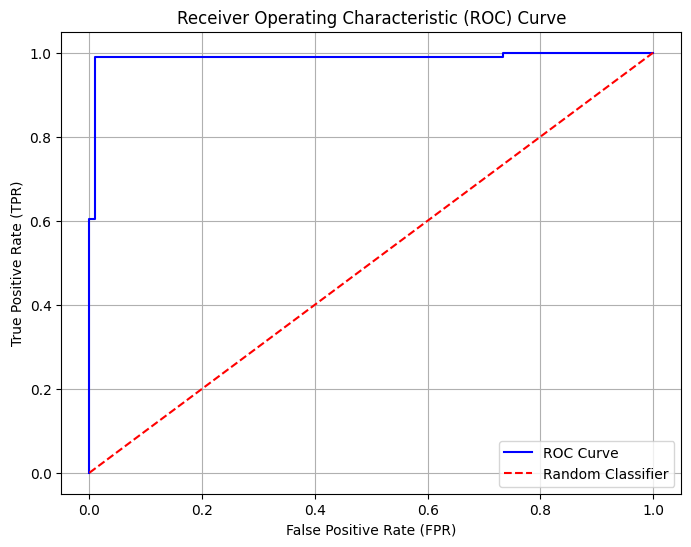

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
import plotly.graph_objects as go

# Create an interactive ROC curve using Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines+markers',
    name='ROC Curve',
    text=[f'Threshold: {t:.4f}<br>FPR: {f:.4f}<br>TPR: {tp:.4f}' for t, f, tp in zip(threshold, fpr, tpr)],
    hoverinfo='text'
))

fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    line=dict(dash='dash', color='red'),
    name='Random Classifier',
    hoverinfo='none'
))

# Add annotations for each threshold to make them explicitly visible
annotations = []
for i in range(len(threshold)):
    # Skip the 'inf' threshold for annotation as it's not a practical decision threshold
    if threshold[i] == float('inf'):
        continue

    annotations.append(
        dict(
            x=fpr[i],
            y=tpr[i],
            xref="x",
            yref="y",
            text=f'T: {threshold[i]:.2f}', # Display simplified threshold value
            showarrow=True,
            arrowhead=1,
            ax=20,
            ay=-30 # Adjust arrow position if needed
        )
    )

fig.update_layout(
    title=go.layout.Title(text='Receiver Operating Characteristic (ROC) Curve with Thresholds'),
    xaxis=go.layout.XAxis(title=go.layout.xaxis.Title(text='False Positive Rate (FPR)')),
    yaxis=go.layout.YAxis(title=go.layout.yaxis.Title(text='True Positive Rate (TPR)')),
    annotations=annotations
)

fig.show()